#### [ Pytorch DL MODEL 실습 ]

- 데이터셋 : iris.csv 
- 학습방법 : 지도학습 + 분류 ==>  다중분류

[1] 모듈로딩 및 데이터 준비<hr>

In [1]:
## 모듈로딩
import pandas as pd                                     ## 데이터 관련 모듈들
import numpy as np 

import torch                                            ## Tensor 및 기본 함수들 관련 모듈들
import torch.nn as nn                                   ## 인공신경망 관련 모듈들
import torch.nn.functional as F                         ## 인공신경망 관련 함수들
import torch.optim as optim                             ## 최적화 모듈
from torch.utils.data import Dataset, DataLoader        ## 학습 데이터셋 관련 모듈

from sklearn.model_selection import train_test_split    ## 학습용 데이터셋 관련 함수

from torchmetrics.classification import *               ## 분류 성능 지표

In [2]:
## 데이터 준비
DATA_FILE = '../_data/iris.csv'

[2] 데이터 로딩 및 확인<hr>

In [3]:
## 데이터 로딩
irisDF = pd.read_csv(DATA_FILE)

irisDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
## 데이터 확인
irisDF.variety.unique()

array(['Setosa', 'Versicolor', 'Virginica'], dtype=object)

In [5]:
pd.set_option('future.no_silent_downcasting', True)
irisDF.variety=irisDF.variety.replace({'Setosa':0, 'Versicolor':1, 'Virginica':2})

In [6]:
irisDF.variety=irisDF.variety.astype('int')
irisDF.dtypes

sepal.length    float64
sepal.width     float64
petal.length    float64
petal.width     float64
variety           int64
dtype: object

[3] 데이터 셋 준비<hr>

In [7]:
## 피쳐와 타겟 분리 
featureDF =irisDF[irisDF.columns[:-1]]   # Feature 4개
targetSR = irisDF[irisDF.columns[-1]]    # 품종 1개

print(f'[FeatureDF] {featureDF.shape}, {featureDF.ndim}D')
print(f'[targetSR]  {targetSR.shape},  {targetSR.ndim}D')

[FeatureDF] (150, 4), 2D
[targetSR]  (150,),  1D


In [8]:
## 학습용, 테스트용 데이터셋 분리 
X_train, X_test, y_train, y_test = train_test_split(featureDF, 
                                                    targetSR, 
                                                    test_size=0.2,
                                                    stratify=targetSR,
                                                    random_state=42)

print(f'[X_train] {X_train.shape}, {X_train.ndim}D  [y_train] {y_train.shape}, {y_train.ndim}D')
print(f'[X_test]  {X_test.shape}, {X_test.ndim}D  [y_test] {y_test.shape}, {y_test.ndim}D')


[X_train] (120, 4), 2D  [y_train] (120,), 1D
[X_test]  (30, 4), 2D  [y_test] (30,), 1D


In [9]:
## 인덱스 재설정 
X_test.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)

X_train.reset_index(drop=True, inplace=True)
y_train.reset_index(drop=True, inplace=True)

In [10]:
# Series => DataFrame : to_frame()
y_train= y_train.to_frame()
y_test = y_test.to_frame()

print(f'y_train : {y_train.shape}   y_test : {y_test.shape}')

y_train : (120, 1)   y_test : (30, 1)


[4] 커스텀 데이터셋 클래스 설계 및 구현 <hr>

In [11]:
## iris 전용 데이터셋 클래스 
class IrisDataset(Dataset):
    # 피쳐와 타겟 분리 및 전처리 진행 
    def __init__(self, featureDF, targetDF):
        super().__init__()
        self.feature = featureDF
        self.target  = targetDF
        self.rows = featureDF.shape[0]
        self.cols = featureDF.shape[1]
    
    # 데이터셋의 샘플 수 반환 메서드 
    def __len__(self):
        return self.rows 

    # DataLoader에서 batch_size만큼 호출하는 메서드
    # 인덱스에 해당하는 피쳐와 타겟 반환 단, Tensor 형태
    def __getitem__(self, index):
       arrFeature = self.feature.iloc[index].values   # ndarray
       arrTarget = self.target.iloc[index].values    # ndarray
   
       return torch.FloatTensor(arrFeature), torch.LongTensor(arrTarget)

In [12]:
## 확인 => Train용 DataSet 필수 
##     => Test용 Dataset 선택 => 데이터가 많다면 DS, DL 생성 사용
##                           => 데이터가 많지 않다면 DS, DL 생성 필요 X 
trainDS = IrisDataset(X_train, y_train)
testDS  = IrisDataset(X_test, y_test)
print( trainDS[1] )
print( testDS[1] )

(tensor([4.9000, 2.5000, 4.5000, 1.7000]), tensor([2]))
(tensor([6.1000, 3.0000, 4.9000, 1.8000]), tensor([2]))


In [13]:
## DataLoader로 확인
trainDL = DataLoader(dataset=trainDS, batch_size=3)
for feature, label in trainDL:
    print(feature, label, sep='\n')
    break

tensor([[4.4000, 2.9000, 1.4000, 0.2000],
        [4.9000, 2.5000, 4.5000, 1.7000],
        [6.8000, 2.8000, 4.8000, 1.4000]])
tensor([[0],
        [2],
        [1]])


In [14]:
# 테스트용 데이터로더
testDL = DataLoader(dataset=testDS, batch_size=3)
for feature, label in testDL:
    print(feature, label, sep='\n')
    break

tensor([[4.4000, 3.0000, 1.3000, 0.2000],
        [6.1000, 3.0000, 4.9000, 1.8000],
        [4.9000, 2.4000, 3.3000, 1.0000]])
tensor([[0],
        [2],
        [1]])


[4] 모델 설계 및 클래스 구현<hr>

In [15]:
# 모델 클래스 설계 ----------------------------------------------------------------------
## 회귀용 커스텀 모델 
## 클래스이름 : IrisModel
## 부모클래스 : nn.Module
## 모델층구성   입력신호/피쳐수       출력신호수/퍼셉트론수       활성화함수
## - 입력층  :      4                     100                 ReLu
## - 은닉층  :     100                     30                 ReLu 
## - 출력층  :      30                     3                  Softmax => 손실함수 내 포함
## - -----------------------------------------------------------------------------------
class IrisModel(nn.Module):
    ## 모델 층 설계 및 초기화 메서드 
    def __init__(self):
        super().__init__()
        self.in_layer  = nn.Linear(4,  100)
        self.hd_layer  = nn.Linear(100, 30)
        self.out_layer = nn.Linear(30,  3)

    ## 학습 진행 메서드 
    def forward(self, data):
        ## 입력층
        out = F.relu( self.in_layer(data) )
        ## 은닉층
        out = F.relu( self.hd_layer(out) )
        ## 출력층
        return self.out_layer(out) 
    

In [16]:
## 모델 구조 확인
model = IrisModel()
print( model )

## shape 체크
data = torch.FloatTensor( [[1.,3.2, 1.9, 2.6]] )   # (1, 4)
model(data)

IrisModel(
  (in_layer): Linear(in_features=4, out_features=100, bias=True)
  (hd_layer): Linear(in_features=100, out_features=30, bias=True)
  (out_layer): Linear(in_features=30, out_features=3, bias=True)
)


tensor([[-0.1985,  0.0788,  0.0422]], grad_fn=<AddmmBackward0>)

In [17]:

## shape 체크
for feature, target  in testDS:
    pre_ = model(feature)
    print(pre_, target)
    print(pre_.max(), pre_.argmax())
    break

tensor([-0.3573,  0.0404,  0.0847], grad_fn=<ViewBackward0>) tensor([0])
tensor(0.0847, grad_fn=<MaxBackward1>) tensor(2)


[5] 학습 준비 <hr>

- [5-1]학습 관련 설정들

In [18]:

EPOCHS      = 70                                   # 학습용 DS을 처음부터 끝까지 1번 학습하는 것을 에포크
BATCH_SIZE  = 40                                    # DS을 학습량 만큼 나눈 사이즈 
ITERATION   = int(X_train.shape[0]/BATCH_SIZE)      # 학습용 DS이 분리된 수 => 1에포크에 W, b 업데이트 횟수

# 학습, 데이터셋 로딩 등 GPU에서 실행 여부 설정 
DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'DEVICE : {DEVICE}, EPOCHS : {EPOCHS}, BATCH_SIZE : {BATCH_SIZE} ITERATION : {ITERATION}')

DEVICE : cpu, EPOCHS : 70, BATCH_SIZE : 40 ITERATION : 3


- [5-2] 학습 관련 인스턴스들

In [19]:
TRAINDL   = DataLoader(trainDS, batch_size=BATCH_SIZE)  #학습용
TESTDL    = DataLoader(testDS,  batch_size=BATCH_SIZE)  #테스트용
LR        = 0.01  
MODEL     = IrisModel()                             ## 학습 모델
OPTIMIZER = optim.Adam(MODEL.parameters(), lr=LR)   ## 최적화 즉, 경사하강법 알고리즘으로 W, b의 값 갱신
LOSS_FN   = nn.CrossEntropyLoss()                   ## 다중분류 손실함수


- [5-3] 학습관련 함수들

In [37]:

##- 검증 함수 --------------------------------------------
##- 검증용 데이터셋으로 모델 검증
##- 학습 지속여부 결정 기준이 됨
##- -----------------------------------------------------
def evaluate():
    # 에포크 단위로 검증 => 검증 모드
    MODEL.eval()
    
    # W, b가 업데이트 해제
    with torch.no_grad():
        # 방법1) 테스트용 DL 적용
        T_LOSS, T_ACC, T_PRE, T_RECALL, CNT = 0, 0, 0, 0, 0
        for feature, target in TESTDL:            
            # 검증진행
            pre_y= MODEL(feature)
            
            # 손실 계산
            loss = LOSS_FN(pre_y, target.reshape(-1).long())
            
            # 정확도 계산
            accuracy = MulticlassAccuracy(num_classes=3)
            prescision = MulticlassPrecision(num_classes=3)
            recall = MulticlassRecall(num_classes=3)
            f1 = MulticlassF1Score(num_classes=3)
            
            
            T_PRE += prescision(pre_y, target.reshape(-1)).item()
            T_RECALL += recall(pre_y, target.reshape(-1)).item()
            T_ACC += accuracy(pre_y, target.reshape(-1)).item()
            T_LOSS += loss.item()
            CNT += 1
            return T_LOSS/CNT, T_ACC/CNT#, T_PRE/CNT, T_RECALL/CNT
    
        # 방법2) 전테 테스트데이터
        # DF/SR => Tensor화
        # 검증용 데이터셋 => 텐서화 ndarray ==> tensor변환
        x = torch.FloatTensor(X_test.values) 
        y = torch.FloatTensor(y_test.values)
        
        # 검증진행
        pre_y= MODEL(x)
        
        # 손실 계산
        loss = LOSS_FN(pre_y, y.reshape(-1).long())

        # 정확도 계산
        accuracy = MulticlassAccuracy(num_classes=3)
        acc = accuracy(pre_y, y.reshape(-1))
        
        return loss.item(), acc.item()

In [38]:
##- 학습 함수 --------------------------------------------
##- 학습용 데이터셋으로 모델 검증
##- -----------------------------------------------------
def training():
    # 학습 모드 설정
    model.train()

    E_LOSS = 0
    E_ACC = 0
    #for i in range(ITERATION): 
    for feature, target in TRAINDL:
        # 배치 크기만큼 feature, target 로딩
        print(feature.shape, target.shape)
                                                                            
        # 가중치 기울기 0 초기화
        OPTIMIZER.zero_grad()

        # 학습 진행
        pre_y = MODEL(feature)

        # 손실 계산
        loss = LOSS_FN(pre_y, target.reshape(-1).long())
        
        # 역전파 진행
        loss.backward()

        # 가중치/절편 업데이트
        OPTIMIZER.step()
        
        # 정확도 계산
        accuracy = MulticlassAccuracy(num_classes=3)
        acc = accuracy(pre_y, target.reshape(-1))
       
        E_ACC += acc.item()
        E_LOSS += loss.item()

    return E_LOSS/ITERATION, E_ACC/ITERATION

In [49]:
# 에포크 : DS 처음부터 ~ 끝까지 학습  
HIST ={'Train':[], 'Valid':[]}   

# 에포크 단위 학습/검증 진행 
for epoch in range(EPOCHS):
    trainLoss, trainAcc = training()
    validLoss, validAcc = evaluate()

    HIST['Train'].append((trainLoss, trainAcc))
    HIST['Valid'].append((validLoss, validAcc))

    print(f'\nEPOCH[{epoch}/{EPOCHS}]----------------')
    print(f'- TRAIN_LOSS {trainLoss:.5f}    ACC {trainAcc:.5f}')
    print(f'- VALID_LOSS {validLoss:.5f}    ACC {validAcc:.5f}')

torch.Size([40, 4]) torch.Size([40, 1])
torch.Size([40, 4]) torch.Size([40, 1])
torch.Size([40, 4]) torch.Size([40, 1])

EPOCH[0/70]----------------
- TRAIN_LOSS 0.05455    ACC 0.98333
- VALID_LOSS 0.04056    ACC 1.00000
torch.Size([40, 4]) torch.Size([40, 1])
torch.Size([40, 4]) torch.Size([40, 1])
torch.Size([40, 4]) torch.Size([40, 1])

EPOCH[1/70]----------------
- TRAIN_LOSS 0.05440    ACC 0.98333
- VALID_LOSS 0.04063    ACC 1.00000
torch.Size([40, 4]) torch.Size([40, 1])
torch.Size([40, 4]) torch.Size([40, 1])
torch.Size([40, 4]) torch.Size([40, 1])

EPOCH[2/70]----------------
- TRAIN_LOSS 0.05425    ACC 0.98333
- VALID_LOSS 0.04070    ACC 1.00000
torch.Size([40, 4]) torch.Size([40, 1])
torch.Size([40, 4]) torch.Size([40, 1])
torch.Size([40, 4]) torch.Size([40, 1])

EPOCH[3/70]----------------
- TRAIN_LOSS 0.05411    ACC 0.98333
- VALID_LOSS 0.04078    ACC 1.00000
torch.Size([40, 4]) torch.Size([40, 1])
torch.Size([40, 4]) torch.Size([40, 1])
torch.Size([40, 4]) torch.Size([40, 

In [60]:
tloss = []
tacc = []
for loss, acc in HIST['Train']:
    tloss.append(loss)
    tacc.append(acc)

vloss = []
vacc = []
for loss, acc in HIST['Valid']:
    vloss.append(loss)
    vacc.append(acc)



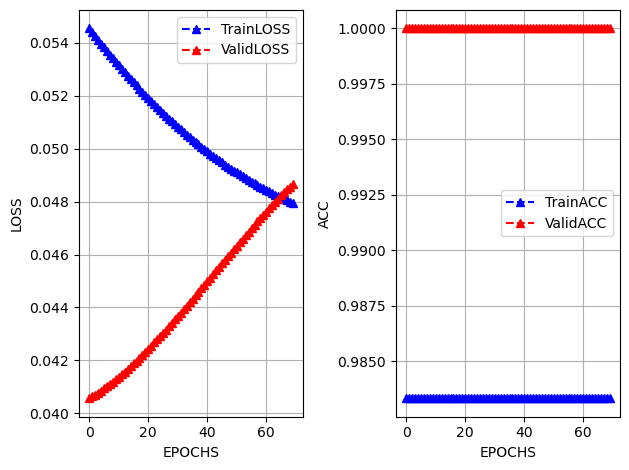

In [68]:
## 모델 성능 시각화 
import matplotlib.pyplot as plt

# plt.plot(HIST['Train'][0], 'b^--', label='TrainLOSS')
# plt.plot(HIST['Valid'][0], 'r^--', label='ValidLOSS')
# plt.plot(HIST['Train'][1], 'bo--', label='TrainACC')
# plt.plot(HIST['Valid'][1], 'ro--', label='ValidACC')

fig, ax = plt.subplots(1,2)
ax = ax.flatten()
ax[0].plot(tloss, 'b^--', label='TrainLOSS')
ax[1].plot(tacc, 'b^--', label='TrainACC')

ax[0].plot(vloss, 'r^--', label='ValidLOSS')
ax[1].plot(vacc, 'r^--', label='ValidACC')


ax[0].grid()
ax[1].grid()
ax[0].legend()
ax[1].legend()
ax[0].set_xlabel('EPOCHS')
ax[1].set_xlabel('EPOCHS')

ax[0].set_ylabel('LOSS')
ax[1].set_ylabel('ACC')
plt.tight_layout()
plt.show()